# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [1]:
# Import necessary libraries 🔧
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
# City: Denver, Colorado (Inside Airbnb data scraped June 30, 2026)
df = pd.read_csv("/content/listings.csv.gz")

print(df.shape)
df.head()


(4939, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,360,https://www.airbnb.com/rooms/360,20260630053644,2026-06-30,city scrape,Denver’s Peaceful Oasis for Travel Nurses & No...,Enjoy the famous Colorado weather and unplug i...,NaN,https://a0.muscache.com/pictures/monet/Select-...,666,...,4.99,4.98,4.90,2017-BFN-0002177,NaN,1,1,0,0,1.94
1,364,https://www.airbnb.com/rooms/364,20260630053644,2026-07-02,previous scrape,Lodo / RiNo LOFT via airport train,"Modern 1,000 square foot loft in the heart of ...",NaN,https://a0.muscache.com/pictures/11766413/a2c5...,783,...,4.96,4.65,4.71,NaN,NaN,1,1,0,0,0.42
2,592,https://www.airbnb.com/rooms/592,20260630053644,2026-06-30,city scrape,private,This room is in the basement. It does not hav...,NaN,https://a0.muscache.com/pictures/ba522ff9-84c9...,933,...,4.96,4.84,4.88,2021-BFN-0000578,NaN,1,0,1,0,1.05
3,686,https://www.airbnb.com/rooms/686,20260630053644,2026-06-30,city scrape,Alexandra's Queen Bed Room Long-term Rental Only,Thanks for visiting my Queen Bed Room for LONG...,NaN,https://a0.muscache.com/pictures/108112/e6d5d3...,990,...,4.91,4.87,4.82,NaN,NaN,1,0,1,0,1.16
4,1940,https://www.airbnb.com/rooms/1940,20260630053644,2026-06-30,city scrape,"Baker Studio Pet-friendly, Walkable, Patio",Private studio retreat in a charming historic ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,2150,...,4.99,4.90,4.90,2018-BFN-0002596,NaN,2,2,0,0,2.42


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

47 of 90 columns have missing values


,missing_count,percent_missing
neighborhood_overview,4939,100.0
host_since,4939,100.0
host_response_time,4939,100.0
host_thumbnail_url,4939,100.0
host_acceptance_rate,4939,100.0
host_response_rate,4939,100.0
host_verifications,4939,100.0
neighbourhood,4939,100.0
host_total_listings_count,4939,100.0
host_neighbourhood,4939,100.0


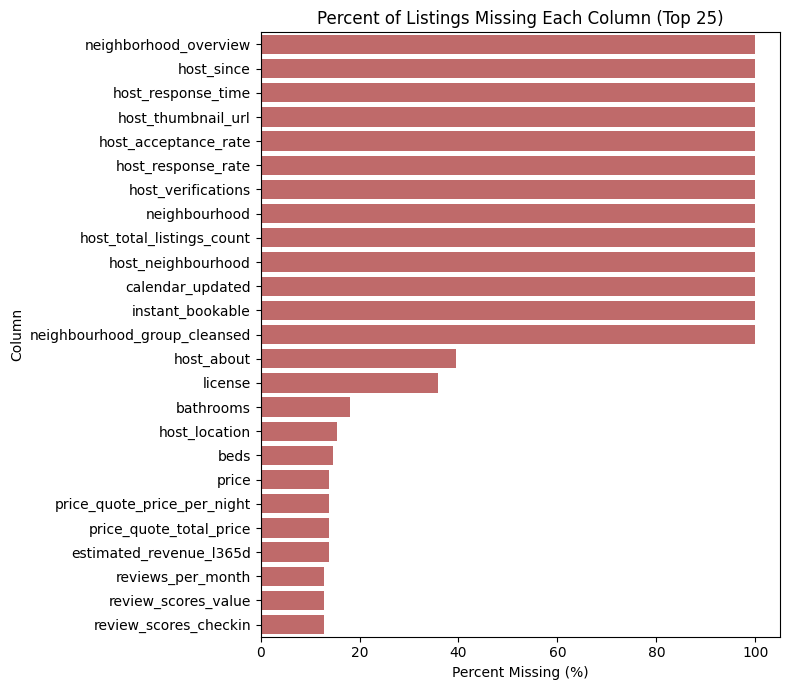

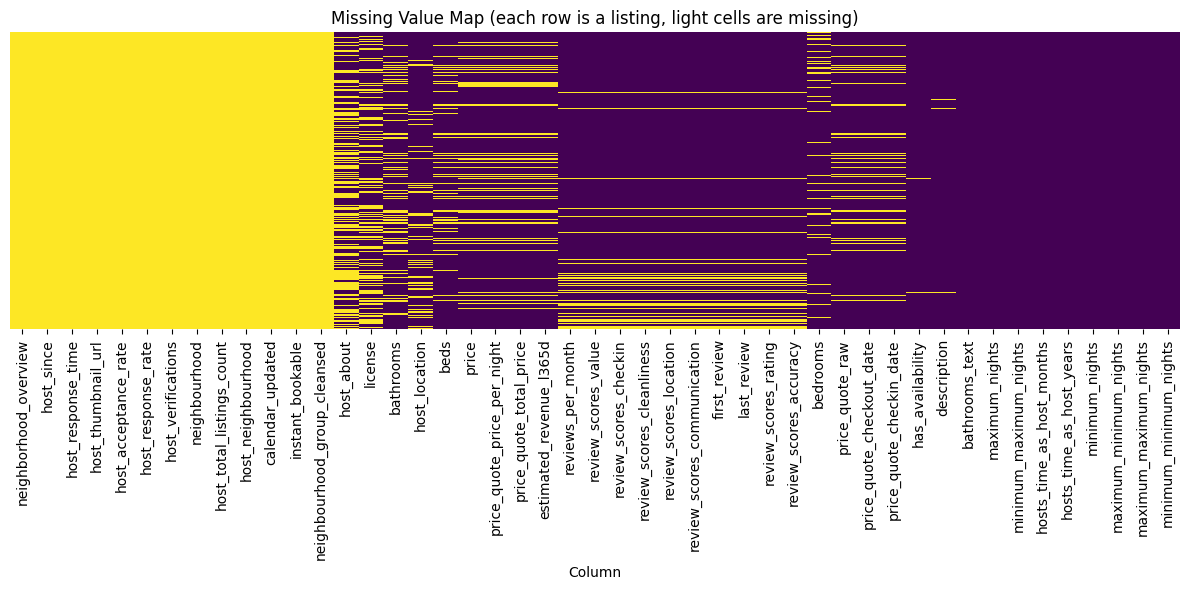

In [3]:
# Add code here 🔧

# Count of null values in each column (sorted, only columns with at least one missing value)
nulls = df.isnull().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]
pct_missing = (nulls / len(df) * 100).round(1)
missing_table = pd.DataFrame({'missing_count': nulls, 'percent_missing': pct_missing})
print(f"{len(missing_table)} of {df.shape[1]} columns have missing values")
display(missing_table)

# Visual 1: bar chart of percent missing for the 25 emptiest columns
top25 = pct_missing.head(25)
plt.figure(figsize=(8, 7))
sns.barplot(x=top25.values, y=top25.index, color='indianred')
plt.title("Percent of Listings Missing Each Column (Top 25)")
plt.xlabel("Percent Missing (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

# Visual 2: heatmap of where values are missing (light = missing) for columns with any nulls
plt.figure(figsize=(12, 6))
sns.heatmap(df[missing_table.index].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Value Map (each row is a listing, light cells are missing)")
plt.xlabel("Column")
plt.tight_layout()
plt.show()


### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. There's a 13-way tie for first place. 13 columns are **100% empty** in the Denver file, including `host_response_time`, `host_response_rate` and `host_acceptance_rate` (the rest are listed in the table above). After those, the columns with the most missing values are `host_about` (39.4% missing), `license` (35.9%) and `bathrooms` (18.0%). In total, 47 of the 90 columns have at least one missing value.

2. The most important gaps are in `price` (688 listings, 13.9%) and the review score columns (638 listings, 12.9%). Price drives pricing models, revenue estimates (`estimated_revenue_l365d` is missing in the same 688 rows) and any price map. Missing review scores could make new listings look bad or disappear from quality rankings. Missing `license` values (35.9%) matter to a city policy team, because Denver requires a short-term rental license. Missing `beds` and `bedrooms` affect capacity and price-per-bed comparisons.

3. The 13 completely empty columns can be dropped safely, since they contain no information. Free-text or link columns like `host_about` and `host_location` can also be ignored for most pricing and mapping work.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [4]:
# Add code here 🔧
print("Columns before dropping:", df.shape[1])

# Step 1: drop every column that is 100% empty. These have no information at all.
fully_empty = df.columns[df.isnull().all()].tolist()
print(f"{len(fully_empty)} completely empty columns:", fully_empty)

# Step 2: drop four more columns chosen on purpose (reasons in the reflection below)
chosen_to_drop = [
    'scrape_id',        # the same value (the scrape run number) on every row
    'price_quote_raw',  # a raw JSON text blob that repeats the price_quote_* columns
    'host_about',       # free-text host bio, 39% missing, not used for pricing or mapping
    'host_picture_url', # a link to the host's photo, no analytical value
]
print("Values in scrape_id:", df['scrape_id'].nunique())

df = df.drop(columns=fully_empty + chosen_to_drop)

print("Columns after dropping:", df.shape[1])
df.info()


Columns before dropping: 90
13 completely empty columns: ['neighborhood_overview', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated', 'instant_bookable']
Values in scrape_id: 1
Columns after dropping: 73
<class 'pandas.DataFrame'>
RangeIndex: 4939 entries, 0 to 4938
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4939 non-null   int64  
 1   listing_url                                   4939 non-null   str    
 2   last_scraped                                  4939 non-null   str    
 3   source                                        4939 non-null   str    
 4   name                                          4939

### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. First, I dropped the 13 columns that were 100% empty (for example `host_response_rate`, `host_acceptance_rate`, `calendar_updated` and `instant_bookable`). Then I chose four more to drop: `scrape_id`, `price_quote_raw`, `host_about` and `host_picture_url`. The dataset went from 90 to 73 columns.

2. The empty columns have no values, so they can't answer any question. `scrape_id` has the same value on every row (it only identifies the data download). `price_quote_raw` is a raw JSON text blob that repeats information already in the `price_quote_*` columns. `host_about` is a free-text host bio that's 39% missing and isn't used for pricing, mapping or availability. `host_picture_url` is just a link to a photo.

3. Leaving them in makes the file bigger and harder to read, and it adds noise to missing-value summaries and dashboards. Empty or constant columns can also break models or charts that expect real values. The raw JSON column could be misread as a second price field. A teammate might also waste time trying to analyze columns that can never have data.


## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [5]:
# Your code for filling / fixing values in key columns 🔧

# Column 1: beds (728 missing)
# The number of beds depends on how many guests the listing holds, so fill each missing value with
# the median beds for listings that accommodate the same number of guests.
print("Missing beds before:", df['beds'].isnull().sum())
df['beds'] = df['beds'].fillna(df.groupby('accommodates')['beds'].transform('median'))
df['beds'] = df['beds'].fillna(df['beds'].median())   # backup for any group with no data
print("Missing beds after:", df['beds'].isnull().sum())

# Column 2: reviews_per_month (638 missing)
# Every missing value belongs to a listing with 0 reviews, so the true value is 0, not unknown.
print("\nMissing reviews_per_month before:", df['reviews_per_month'].isnull().sum())
print("...of those, listings with 0 reviews:",
      ((df['number_of_reviews'] == 0) & df['reviews_per_month'].isnull()).sum())
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
print("Missing reviews_per_month after:", df['reviews_per_month'].isnull().sum())

# Flag (instead of fill) the review score columns: a new listing with no reviews has no rating,
# and filling it with an average would invent a rating that doesn't exist.
df['has_reviews'] = df['number_of_reviews'] > 0
print("\nListings with no reviews yet (review scores left blank on purpose):", (~df['has_reviews']).sum())


Missing beds before: 728
Missing beds after: 0

Missing reviews_per_month before: 638
...of those, listings with 0 reviews: 638
Missing reviews_per_month after: 0

Listings with no reviews yet (review scores left blank on purpose): 638


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. I cleaned `beds` (728 missing) and `reviews_per_month` (638 missing). I also added a `has_reviews` flag column instead of filling the review scores.

2. For `beds`, I filled each blank with the **median number of beds for listings that hold the same number of guests** (`accommodates`). For example, a listing for 4 guests gets 2 beds. That's more realistic than using one overall median for every listing. For `reviews_per_month`, all 638 blanks belong to listings with **0 reviews**, so the correct value is 0 and I filled with 0. I left the review *scores* blank and flagged them with `has_reviews`, because a new listing doesn't have a rating, and filling it with an average would invent one.

3. The filled `beds` values are estimates. A listing that sleeps 4 might really have 1 large bed or 4 twin beds, so price-per-bed calculations for those 728 listings are less certain. Filling `reviews_per_month` with 0 is accurate, but analysts need to remember that 638 listings are brand new and not "unpopular." Leaving review scores blank means any analysis of ratings has to filter on `has_reviews`, or the averages will only describe reviewed listings.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

price dtype before: str
0    $106.35
1     $32.35
2     $80.00
3     $44.27
4    $191.72
Name: price, dtype: str

price dtype after: float64


count      4251.00
mean        276.04
std        1753.13
min           7.38
25%         106.00
50%         176.45
75%         291.00
max      110616.60
Name: price, dtype: float64

room_type
Entire home/apt    190.59
Hotel room         378.00
Private room       106.00
Shared room         35.00
Name: median_price, dtype: float64

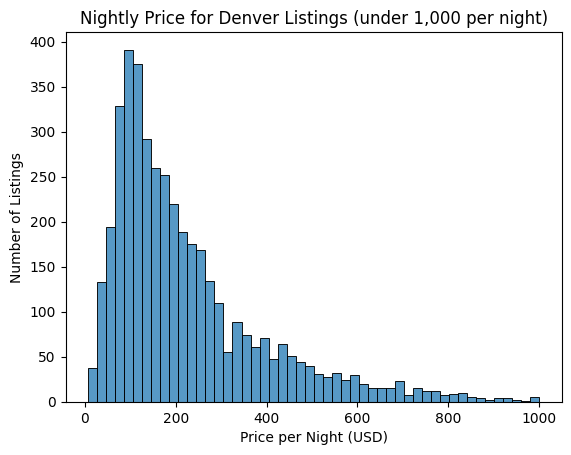

price                       float64
host_is_superhost              bool
first_review         datetime64[us]
last_review          datetime64[us]
room_type                  category
dtype: object

In [6]:
# Clean or adjust your dataset 🔧

# Main fix: price is stored as text like "$1,106.35", so it can't be averaged or plotted
print("price dtype before:", df['price'].dtype)
print(df['price'].head())

df['price'] = (df['price']
               .str.replace('$', '', regex=False)   # remove dollar signs
               .str.replace(',', '', regex=False)   # remove thousands commas
               .astype(float))                      # convert to a number (blanks stay NaN)

print("\nprice dtype after:", df['price'].dtype)
display(df['price'].describe().round(2))

# Check the work: summary by room type and a histogram (limited to under 1,000 per night to see the shape)
display(df.groupby('room_type')['price'].median().round(2).rename('median_price'))

sns.histplot(df.loc[df['price'] < 1000, 'price'], bins=50)
plt.title("Nightly Price for Denver Listings (under 1,000 per night)")
plt.xlabel("Price per Night (USD)")
plt.ylabel("Number of Listings")
plt.show()

# Smaller type fixes so the exported file is ready for Assignment 7
for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability']:
    df[col] = df[col].map({'t': True, 'f': False})          # 't'/'f' text -> True/False
for col in ['last_scraped', 'calendar_last_scraped', 'first_review', 'last_review']:
    df[col] = pd.to_datetime(df[col])                        # text -> real dates
df['room_type'] = df['room_type'].astype('category')

df[['price', 'host_is_superhost', 'first_review', 'last_review', 'room_type']].dtypes


### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. I fixed `price`. It was stored as text like "＄106.35" and "＄1,106.35", so pandas treated it as a string instead of a number.

2. I removed the dollar signs and commas with `.str.replace()` and converted the result to a number with `.astype(float)`. Blank prices stayed as missing values (688 listings). I checked the result with `.describe()`, the median price by room type, and a histogram. The median nightly price is about ＄176. Entire homes have a median of about ＄191, private rooms ＄106, shared rooms ＄35 and hotel rooms ＄378. I also converted the `t`/`f` columns (like `host_is_superhost`) to True/False, the review and scrape dates to real dates, and `room_type` to a category.

3. Now price can be averaged, grouped, plotted and used in models. For example, Assignment 7 can create price per bed or price per guest. The conversion also exposed problems that were hidden while price was text. The maximum is ＄110,616.60 a night, and 62 listings are over ＄1,000, so those need an outlier check before any pricing analysis.


## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates 
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs 
- Remove duplicates if found 

In [7]:
# Add code here 🔧

# 1. Exact duplicate rows
print("Exact duplicate rows:", df.duplicated().sum())

# 2. Each listing id should be unique
print("Duplicate listing ids:", df['id'].duplicated().sum())

# 3. Extra check: same host, same title, same exact location (possible re-posted listing)
near_dups = df[df.duplicated(subset=['host_id', 'name', 'latitude', 'longitude'], keep=False)]
print("Listings that share host, title and location with another listing:", len(near_dups))
display(near_dups.sort_values(['host_id', 'name'])[
    ['id', 'host_id', 'name', 'price', 'bedrooms', 'number_of_reviews', 'availability_365']])

# Remove exact duplicates and duplicate ids if any exist (none were found, so row count is unchanged)
rows_before = len(df)
df = df.drop_duplicates()
df = df.drop_duplicates(subset='id', keep='first')
print("Rows before:", rows_before, "| Rows after:", len(df))


Exact duplicate rows: 0
Duplicate listing ids: 0
Listings that share host, title and location with another listing: 6


,id,host_id,name,price,bedrooms,number_of_reviews,availability_365
801,33092434,203341,QuietHomeOfficeExtendedStayWalkableStudioApart...,NaN,NaN,12,0
1197,45505166,203341,QuietHomeOfficeExtendedStayWalkableStudioApart...,NaN,1.0,1,0
2490,851316625586438153,11004312,Walk to Coors Field & RiNo’s Best Bars/Restaur...,837.50,3.0,56,282
2528,864078557262935096,11004312,Walk to Coors Field & RiNo’s Best Bars/Restaur...,696.00,4.0,31,82
4119,1491328104227806195,661490610,"Walk to Sloans Lake! King Bed, Near Food & Tra...",60.26,3.0,0,305
4197,1507334776836823544,661490610,"Walk to Sloans Lake! King Bed, Near Food & Tra...",47.31,1.0,0,337


Rows before: 4939 | Rows after: 4939


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. No. There were 0 exact duplicate rows and 0 duplicate listing IDs, so every one of the 4,939 listings is unique. My extra check found 3 pairs of listings (6 rows) with the same host, the same title and the exact same location.

2. I looked at those 3 pairs side by side, and they have different listing IDs, prices, bedroom counts and review counts. For example, the "Walk to Coors Field" pair has one 3-bedroom unit at about 838 USD and one 4-bedroom unit at 696 USD a night. That means they're most likely separate units the same host runs in one building, not copies, so I kept them. I still ran `drop_duplicates()` on full rows and on `id` so the code protects against duplicates if the file is updated, but it removed 0 rows.

3. Duplicates would double-count a listing's revenue, reviews and availability. That inflates market size and revenue estimates, skews average prices for a neighborhood, and can show the same home twice to guests or on a map. For a city policy team, a duplicate could also make it look like there are more short-term rentals (or unlicensed listings) than there really are.


## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”) 
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP 
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP 

```





In [8]:
# export csv here 🔧
df.to_csv("cleaned_airbnb_data_6.csv", index=False)

print("Saved cleaned_airbnb_data_6.csv with shape", df.shape)


Saved cleaned_airbnb_data_6.csv with shape (4939, 74)


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts? 
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information) 
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. The most challenging part was section 3, deciding which columns to drop. The coding was simple, but with 90 columns I had to understand what each one meant and decide whether it had business value. The assignment says to drop 2–4 columns, but 13 columns were completely empty, so I had to decide how to handle both. I applied the class concept that data preparation should keep only what supports the business question.

2. `reviews_per_month` is a good example of fixing data. It was missing for 638 listings, but every one of them had 0 reviews, so the right fix was to fill with 0 instead of the median or dropping the rows. For the review *scores*, I kept the blanks and added a `has_reviews` flag, because a new listing hasn't earned a rating yet. Filling in an average would have invented quality information that doesn't exist.

3. A pricing analyst could now compare nightly prices across Denver neighborhoods and room types right away, since price is a real number. They could also build a map of listings with prices and ratings without blank or text fields breaking it. A city policy team could use the cleaned `license` and listing counts to see how many listings are missing a license number.

4. I would look more closely at price outliers (a ＄110,616 nightly price and 62 listings over ＄1,000) and at the 688 listings with no price, 379 of which aren't available at all in the next year. I'd also fill `bathrooms` from the `bathrooms_text` column (e.g. "1.5 shared baths"), parse `amenities` into separate columns, and check whether the missing licenses are exempt listings or real compliance problems.

5. My learning outcome was about building Python skills and using AI to apply them to accounting and business decisions. This assignment used pandas to clean a real, messy dataset, and I used AI to help write and check the code. Clean, reliable data is the foundation of accurate financial reporting and revenue estimates, which is what I want to be able to do as an accountant.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"